In [1]:
import scirpy as ir
import scanpy as sc
from glob import glob
import pandas as pd
import tarfile
import anndata
import warnings
import scanpy as sc
import anndata as an
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Standard QC function

In [2]:
DUPa_biopsy = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/DUPa_ChromISH_CXCL10/DUPa12/DUPa12_04_analysis.csv', sep = ',')

In [3]:
def qc_true_cells(df):
    true_ccl19 = (
        ((df['CCL19 Positive Cytoplasm'] == 1) & (df['CXCL10 Positive Cytoplasm'] == 0) & (df['Rejection Positive Cytoplasm'] == 0)) |
        ((df['CCL19 Positive Nucleus'] == 1) & (df['CXCL10 Positive Nucleus'] == 0) & (df['Rejection Positive Nucleus'] == 0))
    )

    true_cxcl10 = (
        ((df['CCL19 Positive Cytoplasm'] == 0) & (df['CXCL10 Positive Cytoplasm'] == 1) & (df['Rejection Positive Cytoplasm'] == 0)) |
        ((df['CCL19 Positive Nucleus'] == 0) & (df['CXCL10 Positive Nucleus'] == 1) & (df['Rejection Positive Nucleus'] == 0))
    )

    true_neither = (
        (df['CCL19 Positive Cytoplasm'] == 0) &
        (df['CXCL10 Positive Cytoplasm'] == 0) &
        (df['CCL19 Positive Nucleus'] == 0) &
        (df['CXCL10 Positive Nucleus'] == 0) &
        (df['Rejection Positive Cytoplasm'] == 0) &
        (df['Rejection Positive Nucleus'] == 0)
    )

    # Combine accepted categories
    all_cells = true_ccl19 | true_cxcl10 | true_neither

    # Add QC step: exclude any row with Rejection Positive in nucleus or cytoplasm
    rejection_cells = (df['Rejection Positive Cytoplasm'] == 0) & (df['Rejection Positive Nucleus'] == 0)

    # Combine both masks
    final_cells = all_cells & rejection_cells
    df_filtered = df[final_cells].copy()

    # Add indicator columns
    df_filtered['True_CCL19'] = true_ccl19[final_cells].astype(int)
    df_filtered['True_CXCL10'] = true_cxcl10[final_cells].astype(int)
    df_filtered['True_Neither'] = true_neither[final_cells].astype(int)

    return df_filtered

In [4]:
print(len(DUPa_biopsy))
DUPa_biopsy_post_QC = qc_true_cells(DUPa_biopsy)
print(len(DUPa_biopsy_post_QC))

7182
7057


# Simple counting number of cells that are CXCL10+ or CCL19+ 

In [5]:
# count CXCL10+ cells, CCL19+ cells. calculate percentages
cxcl10_count = (DUPa_biopsy_post_QC['True_CXCL10'] == 1).sum()
ccl19_count = (DUPa_biopsy_post_QC['True_CCL19'] == 1).sum()
print('CXCL10+: '+ str(cxcl10_count) + ', CCL19+: ' + str(ccl19_count))
print('CXCL10+ percentage: ' + str(100*cxcl10_count/len(DUPa_biopsy_post_QC)))
print('CCL19+ percentage: ' + str(100*ccl19_count/len(DUPa_biopsy_post_QC)))


CXCL10+: 254, CCL19+: 247
CXCL10+ percentage: 3.599263142978603
CCL19+ percentage: 3.5000708516366728


# Hexagon Tiling Analysis: (PMID: 38503922)

In [6]:
from matplotlib.patches import RegularPolygon
from scipy.spatial import cKDTree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creates hexagon tiles of area 2500 microns across grid. Saves hexagon grid image as DUPa_Tile_Grid.
def plot_hex_tiling(df, area=2500, save_path='DUPa_Tile_Grid.pdf'):
    
    # Center of cell is average of min and max. Then, convert from pixels to microns (4:1 ratio).
    df['center_x'] = ((df['XMin'] + df['XMax']) / 2) * 0.25 
    df['center_y'] = ((df['YMin'] + df['YMax']) / 2) * 0.25
    x = df['center_x'].values
    y = df['center_y'].values
    CXCL1011_positive = (df['True_CXCL10'] == 1).astype(int).values
    CCL19_positive = (df['True_CCL19'] == 1).astype(int).values

    # Hex radius from area of hexagon
    r = np.sqrt((2 * area) / (3 * np.sqrt(3))) 
    pad = 3 * r
    x_min, x_max = x.min() - pad, x.max() + pad
    y_min, y_max = y.min() - pad, y.max() + pad

    # Sets the number of tiles per column and row.
    hex_width = np.sqrt(3) * r
    hex_height = 2 * r
    cols = int((x_max - x_min) / hex_width) + 2
    rows = int((y_max - y_min) / (hex_height * 0.75)) + 2

    # Places tiles in the grid, appending coordinates of each center to list hex_centers.
    hex_centers = []
    for row in range(rows):
        for col in range(cols):
            x_offset = x_min + col * hex_width
            if row % 2 == 1:
                x_offset += hex_width / 2
            y_offset = y_min + row * hex_height * 0.75
            if x_offset <= x_max and y_offset <= y_max:
                hex_centers.append((x_offset, y_offset))
    
    # Build spatial index to assign cells to closest hex center
    tree = cKDTree(hex_centers)
    distances, indices = tree.query(np.vstack([x, y]).T)

    # Count cells per tile & marker-positive cells
    tile_counts = {}
    tile_CXCL1011_counts = {}
    tile_CCL19_counts = {}
    for idx, CXCL1011, CCL19 in zip(indices, CXCL1011_positive, CCL19_positive):
        tile_counts[idx] = tile_counts.get(idx, 0) + 1
        tile_CXCL1011_counts[idx] = tile_CXCL1011_counts.get(idx, 0) + CXCL1011
        tile_CCL19_counts[idx] = tile_CCL19_counts.get(idx, 0) + CCL19

    # Plot tiles with colors according to cell counts
    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    for i, (hx, hy) in enumerate(hex_centers):
        CXCL1011 = tile_CXCL1011_counts.get(i, 0)
        CCL19 = tile_CCL19_counts.get(i, 0)
        count = tile_counts.get(i, 0)
        if count == 0: 
            facecolor = '#F0F0F0'  # No cells in tile.
        elif CXCL1011 > 1 and CCL19 > 0:
            facecolor = '#832121'      # At least 2 CXCL10/11+ and at least 1 CCL19+ cells in tile.
        elif CXCL1011 > 1 and CCL19 == 0:
            facecolor = '#FF9999'     # At least 2 CXCL10/11+ and 0 CCL19+ cells in tile.
        elif CCL19 > 0 and CXCL1011 == 0:
            facecolor = '#CC9966'    # 0 CXCL10/11+ cells and at least 1 CCL19+ cell in tile.
        else:
            facecolor = '#0000FF'     # At least 1 cell but 0 CXCL10/11+ or CCL19+.

        hex_patch = RegularPolygon(
            (hx, hy), numVertices=6, radius=r, orientation=0,
            facecolor=facecolor, edgecolor='k', linewidth=0.2
        )
        ax.add_patch(hex_patch)

    # Print tile statistics
    total_tiles = len(hex_centers)
    tiles_with_cells = len(tile_counts)
    tiles_with_both = sum(1 for i in tile_counts if tile_CXCL1011_counts.get(i, 0) > 1 and tile_CCL19_counts.get(i, 0) > 0)
    tiles_CXCL1011_only = sum(1 for i in tile_counts if tile_CXCL1011_counts.get(i, 0) > 1 and tile_CCL19_counts.get(i, 0) == 0)
    tiles_CCL19_only = sum(1 for i in tile_counts if tile_CCL19_counts.get(i, 0) > 0 and tile_CXCL1011_counts.get(i, 0) == 0)
    print(f"Total tiles: {total_tiles}")
    print(f"Tiles with cells: {tiles_with_cells}")
    print(f"Tiles with CXCL10/11: {tiles_CXCL1011_only + tiles_with_both} ")
    print(f"Tiles with CCL19: {tiles_CCL19_only + tiles_with_both}")
    print(f"Tiles with both markers: {tiles_with_both}")

    # Finalize plot
    ax.set_aspect('equal')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.invert_yaxis()
    ax.set_xlabel("X (μm)")
    ax.set_ylabel("Y (μm)")
    ax.set_title("Hex Tiling (2500 μm²)\nRed=2+ CXCL10/11+ & 1+ CCL19+, Pink=2+ CXCL10/11+ only, Brown=1+ CCL19+ only, Blue=Others, Gray=Empty")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save vertex coordinates for ALL tile in grid to CSV
    hex_data = []
    for i in tile_counts:
        hx, hy = hex_centers[i]
        angles = np.deg2rad(np.arange(6) * 60 + 30)  # Vertices of hexagon tile : 30, 90, 150, 210, 270, 330 degrees
        angles = np.append(angles, angles[0])  # Close the tile by returning to first vertex
        for j, angle in enumerate(angles):
            vx = hx + r * np.cos(angle) 
            vy = hy + r * np.sin(angle)
            hex_data.append({
                'hex_index': i,
                'center_x': hx*4,
                'center_y': hy*4,
                'vertex_num': j + 1,
                'vertex_x': vx*4,
                'vertex_y': vy*4
            })

    hex_df = pd.DataFrame(hex_data)
    hex_df.to_csv("tiles_with_cells_vertices.csv", index=False)

    return hex_centers, tile_CXCL1011_counts, tile_CCL19_counts, tile_counts, r


Total tiles: 8928
Tiles with cells: 535
Tiles with CXCL10/11: 53 
Tiles with CCL19: 86
Tiles with both markers: 12


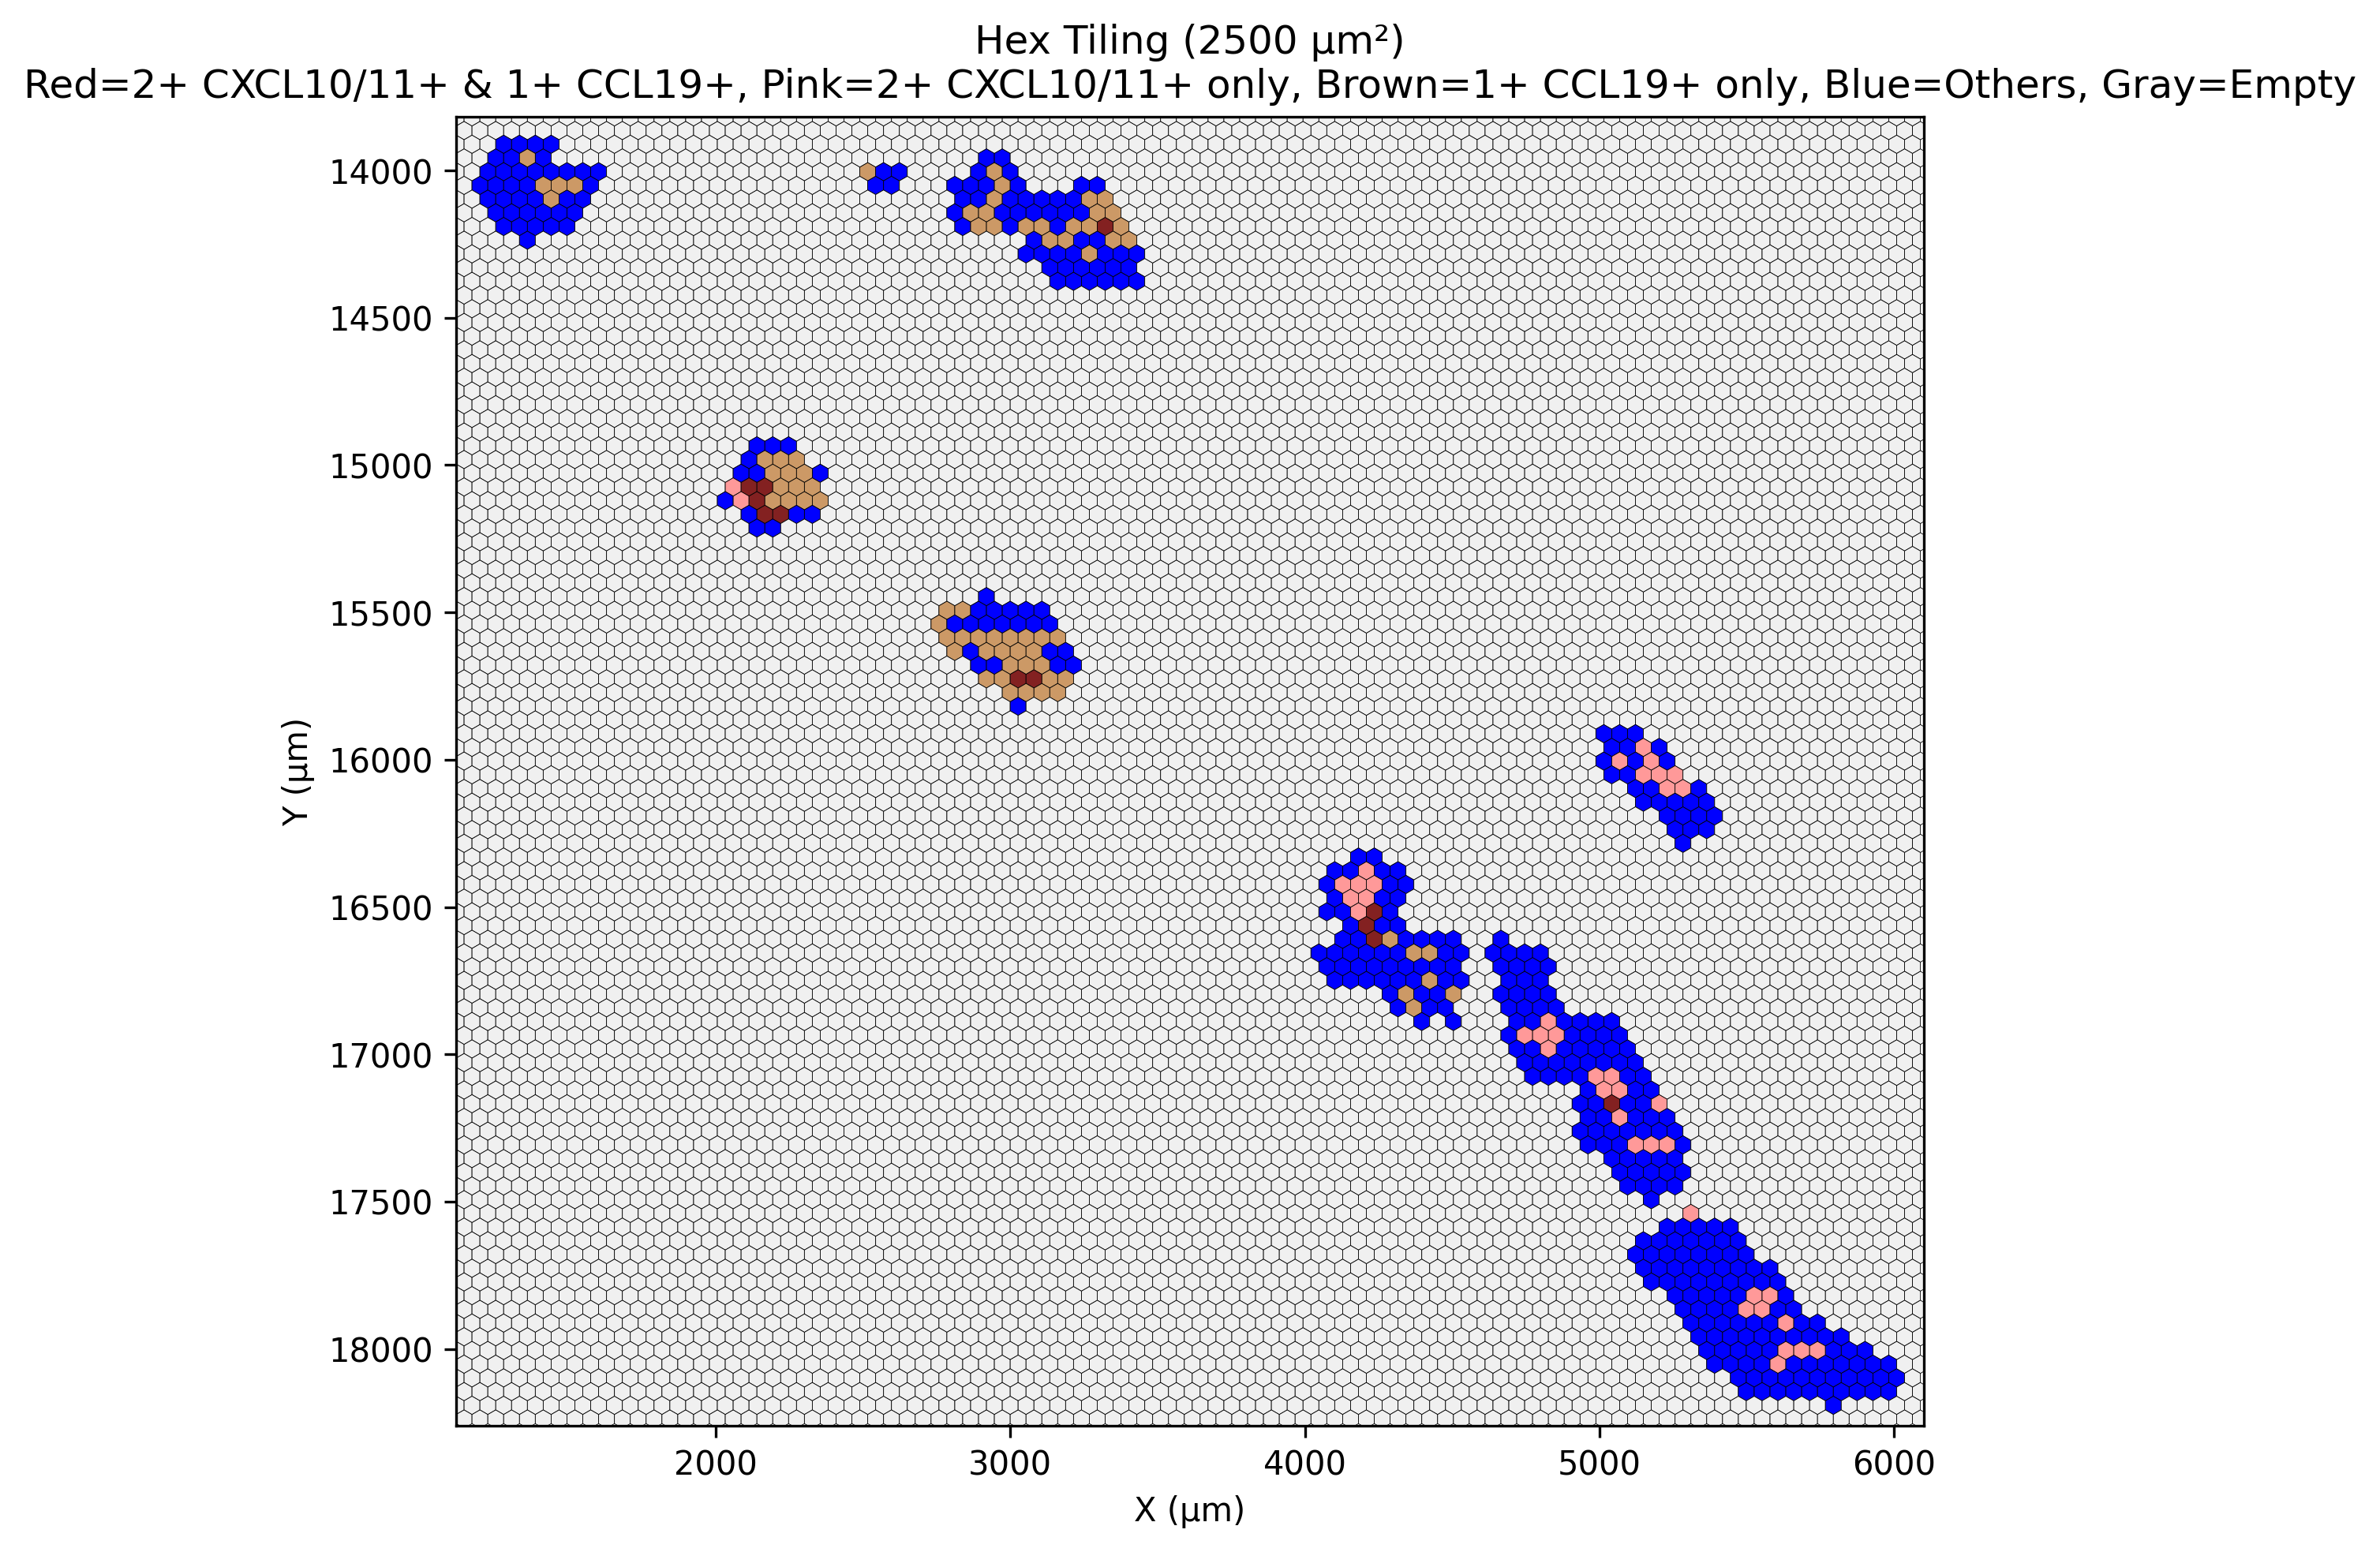

In [7]:
## Run plot and get tile data
hex_centers, tile_CXCL1011_counts, tile_CCL19_counts, tile_counts, r = plot_hex_tiling(DUPa_biopsy_post_QC)

In [1]:
# Run in terminal (sends DUPa_Tile_Grid to Google Cloud):
#  gsutil -m cp -r Alex_Tang_workspace_2023_02_01/edit/DUPa03_06_hexagons.geojson gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/DUPa_ChromISH_CXCL10/DUPa_Overlay_Files
# Change name of destination path for specific DUPa

# Hexagon Tile Analysis Overlay (QuPath)

In [8]:
# Run in terminal (sends tiles_with_cells_vertices to Google Cloud): 
# gsutil -m cp -r Alex_Tang_workspace_2023_02_01/edit/tiles_with_cells_vertices.csv  gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/DUPa_ChromISH_CXCL10/

In [33]:
# Loads in tiles_with_cells_vertices from Google Cloud.
original_coordinates = pd.read_csv("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/DUPa_ChromISH_CXCL10/tiles_with_cells_vertices.csv", sep = ',')
print(original_coordinates)

       hex_index      center_x      center_y  vertex_num      vertex_x  \
0            594  20790.731863   4717.620972           1  20898.188856   
1            594  20790.731863   4717.620972           2  20790.731863   
2            594  20790.731863   4717.620972           3  20683.274870   
3            594  20790.731863   4717.620972           4  20683.274870   
4            594  20790.731863   4717.620972           5  20790.731863   
...          ...           ...           ...         ...           ...   
53391      24296  29817.119291  30774.557027           3  29709.662297   
53392      24296  29817.119291  30774.557027           4  29709.662297   
53393      24296  29817.119291  30774.557027           5  29817.119291   
53394      24296  29817.119291  30774.557027           6  29924.576284   
53395      24296  29817.119291  30774.557027           7  29924.576284   

           vertex_y  
0       4779.661296  
1       4841.701620  
2       4779.661296  
3       4655.580648  
4

In [13]:
# QuPath needs geojson format.
import pandas as pd
import json

def convert_csv_to_geojson(csv_path="original_coordinates.csv", output_path="output_annotations.geojson"):
    # Read CSV and identify coordinate and group columns
    df = pd.read_csv(csv_path)
    x_col = df.columns[-2]
    y_col = df.columns[-1]
    group_col = df.columns[0]

    # Group by polygon ID
    grouped = df.groupby(group_col)

    # Build GeoJSON structure
    geojson = {
        "type": "FeatureCollection",
        "features": []
    }

    for region_id, group in grouped:
        # Build the polygon vertex list
        polygon = [
            [float(row[x_col]), float(row[y_col])]
            for _, row in group.iterrows()
        ]

        # Ensure the polygon is closed
        if polygon[0] != polygon[-1]:
            polygon.append(polygon[0])

        feature = {
            "type": "Feature",
            "properties": {
                "region_id": int(region_id)
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": [polygon]  # GeoJSON requires coordinates in [ [ [x, y], ... ] ] format
            }
        }

        geojson["features"].append(feature)

    # Save to GeoJSON file
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(geojson, f, indent=2)

    print(f"Saved GeoJSON to {output_path}")


In [34]:
# Convert the csv file to geojson.
convert_csv_to_geojson("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/DUPa_ChromISH_CXCL10/tiles_with_cells_vertices.csv", "DUPa09_08_hexagons.geojson")
# Note: Make sure to change name of output_path for specific DUPa.

Saved GeoJSON to DUPa09_08_hexagons.geojson


In [14]:
# Run in terminal (sends hexagon tile file to Google Cloud for download to local device):
# gsutil -m cp -r Alex_Tang_workspace_2023_02_01/edit/DUPa03_06_hexagons.geojson gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/DUPa_ChromISH_CXCL10/DUPa_Overlay_Files
# Note: Make sure to change name of file for specific DUPa.